# 68 — LSEG target materiality measurement pilot

**Candidate question:** does LLM-scored firm-specific economic materiality add information beyond sentiment polarity? This notebook is measurement-only and does not select the dissertation RQ.

The parent sample is selected without prices or returns from the joined same-33 Reuters history. Hosted scoring is separately authorised and resumable; human reliability must pass before any return file may be opened. Licensed text remains in the gitignored output directory and is never displayed here.

In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'final_experiments').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.lseg_materiality import audit_completion_status, materiality_paths
from sentiment_benchmark.artifact_io import atomic_write_json, read_json, read_jsonl

OUTPUT_ROOT = REPO_ROOT / 'final_experiments/outputs/68_lseg_materiality_measurement_pilot'
PATHS = materiality_paths(OUTPUT_ROOT)
FROZEN_SPEC = REPO_ROOT / 'final_experiments/frozen_specs/lseg_target_materiality_pilot_v1_20260812.json'
BODY_AMENDMENT = REPO_ROOT / 'final_experiments/frozen_specs/lseg_target_materiality_pilot_body_availability_amendment_20260812.json'
assert FROZEN_SPEC.is_file() and BODY_AMENDMENT.is_file()
assert PATHS.sample_manifest.is_file() and PATHS.body_manifest.is_file()
sample_manifest = read_json(PATHS.sample_manifest)
body_manifest = read_json(PATHS.body_manifest)
events = pd.DataFrame(read_jsonl(PATHS.sample_events))
body_ids = {path.stem for path in PATHS.body_cache.glob('*.json')}
events['body_available'] = events['audit_id'].isin(body_ids)
events['entry_session'] = pd.to_datetime(events['entry_session'])
assert len(events) == 2_000 and events['headline_sha256'].is_unique
assert not events.duplicated(['symbol', 'entry_session']).any()
assert int(events['body_available'].sum()) == body_manifest['counts']['successful_bodies']
print('prices or returns loaded:', False)
print('sample:', len(events), 'body available:', int(events['body_available'].sum()))

prices or returns loaded: False
sample: 2000 body available: 1445


## Frozen sampling and body-availability audit

The planned 60/61-per-company quota was amended return-blind because SO had only 47 eligible Reuters company-sessions. All 47 were retained and the 13-event shortfall was redistributed deterministically without weakening the source or first-release filters. A complete selective LSEG retrieval pass then fixed the full-text measurement population; unavailable archival shells are attrition, not replacement invitations.

,group,level,selected,body_available,body_available_share
33,source_block,backward_2024_2025,1374,1120,0.815138
34,source_block,opened_2025_2026,626,325,0.519169
35,label_finbert,negative,695,536,0.771223
36,label_finbert,neutral,474,385,0.812236
37,label_finbert,positive,831,524,0.630566


,group,level,selected,body_available,body_available_share
28,symbol,SO,47,12,0.255319
6,symbol,COP,61,32,0.524590
9,symbol,EQIX,61,32,0.524590
22,symbol,NEE,61,34,0.557377
1,symbol,AMT,61,34,0.557377
18,symbol,LIN,61,34,0.557377
23,symbol,NEM,61,35,0.573770
26,symbol,PG,61,36,0.590164
27,symbol,PLD,61,37,0.606557
8,symbol,DUK,61,37,0.606557


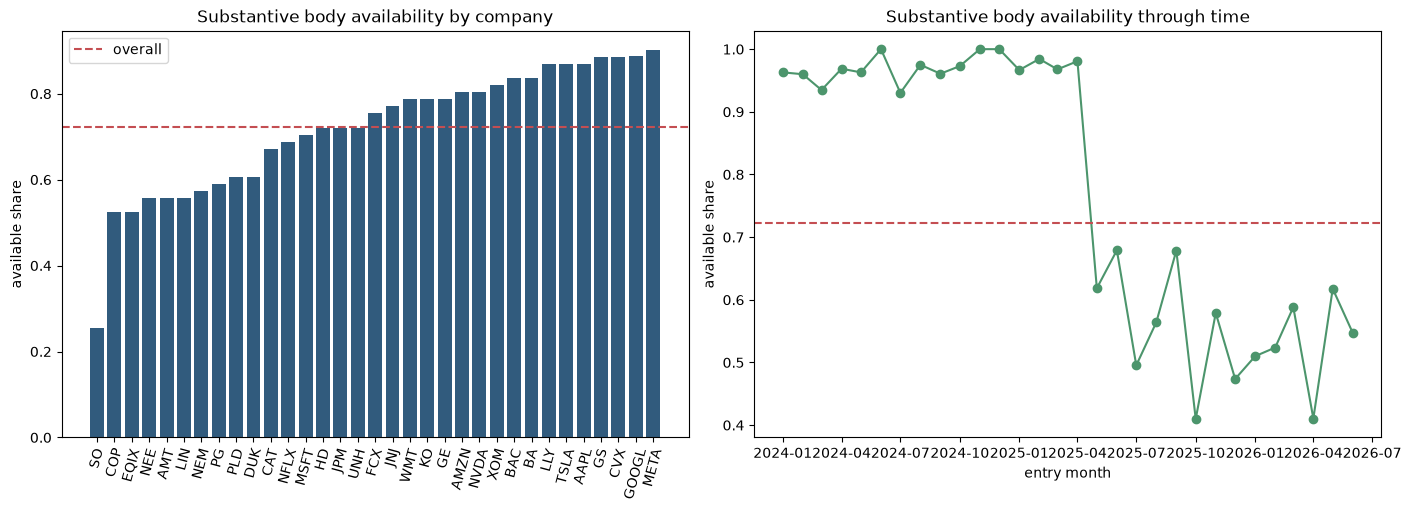

In [2]:
availability_summary = pd.DataFrame([
    {
        'group': group,
        'level': str(level),
        'selected': len(frame),
        'body_available': int(frame['body_available'].sum()),
        'body_available_share': float(frame['body_available'].mean()),
    }
    for group in ('symbol', 'source_block', 'label_finbert')
    for level, frame in events.groupby(group, sort=True)
])
display(availability_summary.loc[availability_summary['group'] != 'symbol'])
display(availability_summary.loc[availability_summary['group'] == 'symbol'].sort_values('body_available_share'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
symbol_table = availability_summary.loc[availability_summary['group'] == 'symbol'].sort_values('body_available_share')
axes[0].bar(symbol_table['level'], symbol_table['body_available_share'], color='#315b7d')
axes[0].axhline(events['body_available'].mean(), color='#c44e52', linestyle='--', label='overall')
axes[0].set_title('Substantive body availability by company')
axes[0].set_ylabel('available share')
axes[0].tick_params(axis='x', rotation=75)
axes[0].legend()
monthly = events.set_index('entry_session').groupby(pd.Grouper(freq='MS'))['body_available'].agg(['size', 'sum', 'mean'])
axes[1].plot(monthly.index, monthly['mean'], marker='o', linewidth=1.5, color='#4c956c')
axes[1].axhline(events['body_available'].mean(), color='#c44e52', linestyle='--')
axes[1].set_title('Substantive body availability through time')
axes[1].set_ylabel('available share')
axes[1].set_xlabel('entry month')
plt.show()

## Measurement progress and hard gate

The joint output is direction/severity, firm-specific economic materiality, novelty, valuation horizon, target specificity and evidence sufficiency. Model annotations are not ground truth. Hosted scoring is complete, and the blinded 200-event primary audit plus 60-event second-code subset are built. Return access remains false until both sheets are independently completed and the separately frozen reliability report passes.

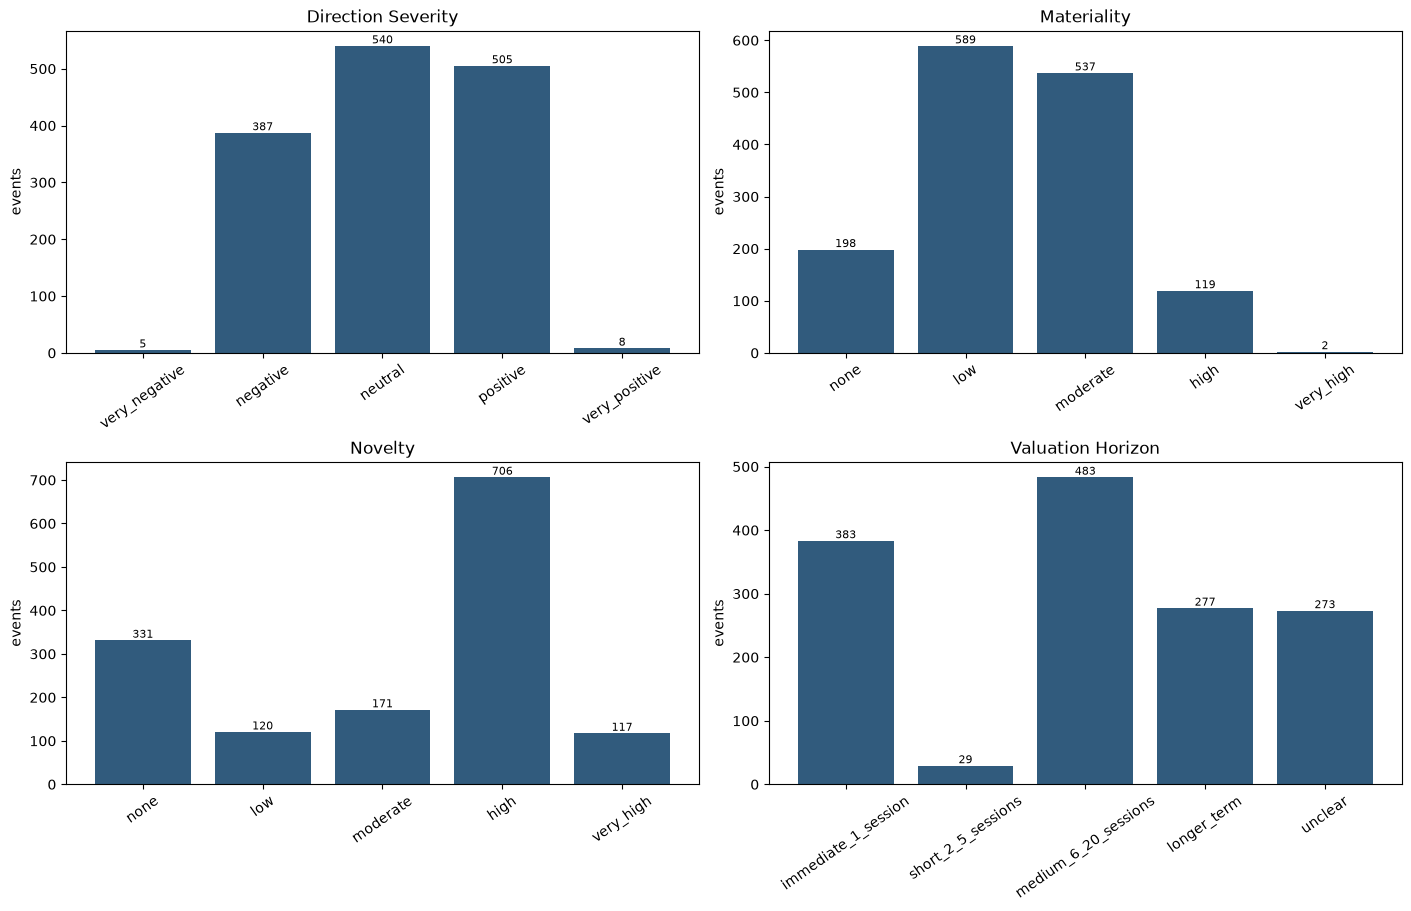

,flag,true_count,true_share
0,target_specific,1296,0.896886
1,evidence_sufficient,1445,1.000000


{'parent_sample': 2000,
 'body_available_measurement_population': 1445,
 'body_available_share': 0.7225,
 'companies': 33,
 'first_entry_session': '2024-01-02',
 'last_entry_session': '2026-06-25',
 'hosted_scoring_status': 'completed',
 'hosted_successes': 1445,
 'hosted_attempt_records': 1450,
 'hosted_reported_cost_usd': 0.18523289,
 'human_gate_status': 'awaiting_human_labels',
 'return_access_allowed': False,
 'prices_or_returns_loaded': False}

In [3]:
score_manifest = read_json(PATHS.score_manifest) if PATHS.score_manifest.is_file() else {'status': 'not_started'}
scores = pd.DataFrame(read_jsonl(PATHS.model_scores)) if PATHS.model_scores.is_file() else pd.DataFrame()
if not scores.empty:
    label_orders = {
        'direction_severity': ['very_negative', 'negative', 'neutral', 'positive', 'very_positive'],
        'materiality': ['none', 'low', 'moderate', 'high', 'very_high'],
        'novelty': ['none', 'low', 'moderate', 'high', 'very_high'],
        'valuation_horizon': ['immediate_1_session', 'short_2_5_sessions', 'medium_6_20_sessions', 'longer_term', 'unclear'],
    }
    figure, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    for axis, (field, order) in zip(axes.flat, label_orders.items(), strict=True):
        counts = scores[field].value_counts().reindex(order, fill_value=0)
        axis.bar(counts.index, counts.values, color='#315b7d')
        axis.set_title(field.replace('_', ' ').title())
        axis.set_ylabel('events')
        axis.tick_params(axis='x', rotation=35)
        for index, value in enumerate(counts.values):
            axis.text(index, value, str(value), ha='center', va='bottom', fontsize=8)
    plt.show()
    display(pd.DataFrame({
        'flag': ['target_specific', 'evidence_sufficient'],
        'true_count': [int(scores['target_specific'].sum()), int(scores['evidence_sufficient'].sum())],
        'true_share': [float(scores['target_specific'].mean()), float(scores['evidence_sufficient'].mean())],
    }))
human_gate = audit_completion_status(output_root=OUTPUT_ROOT)
progress = {
    'parent_sample': len(events),
    'body_available_measurement_population': int(events['body_available'].sum()),
    'body_available_share': float(events['body_available'].mean()),
    'companies': int(events['symbol'].nunique()),
    'first_entry_session': events['entry_session'].min().date().isoformat(),
    'last_entry_session': events['entry_session'].max().date().isoformat(),
    'hosted_scoring_status': score_manifest.get('status'),
    'hosted_successes': (score_manifest.get('counts') or {}).get('successful_unique', 0),
    'hosted_attempt_records': (score_manifest.get('counts') or {}).get('attempt_records', 0),
    'hosted_reported_cost_usd': (score_manifest.get('usage') or {}).get('reported_cost_usd'),
    'human_gate_status': human_gate['status'],
    'return_access_allowed': False,
    'prices_or_returns_loaded': False,
}
atomic_write_json(OUTPUT_ROOT / 'measurement_progress.json', progress)
progress

## Decision

The sample, body-availability population, hosted annotations and blinded audit packets are complete. The active stop is human measurement: coder A must complete 200 rows and an independent coder B must complete the frozen 60-row subset. Gemma's `evidence_sufficient=true` rate is 100%, which is specifically a potential overconfidence defect for the audit to test. No strategy or return claim is available from this notebook.